# Capítulo 16 — Soluções dos exercícios complementares

**Curso de Meteorologia Prática** — baseado em R. Stull, *Practical Meteorology* (CC BY-NC-SA 4.0).

> **Para o professor.** Soluções dos teóricos **T1–T5** e numéricos **N1–N4** do Cap. 16. Não distribuir antes da entrega.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
import sys; sys.path.append('../comum')
from estilo_meteo import aplicar_estilo, CORES
aplicar_estilo()

g, Omega = 9.8, 7.292e-5
rho_ar, rho_agua = 1.15, 1025.0

## T1 — Eficiência de Carnot do furacão

In [2]:
Ts, Tout = 300.0, 200.0
eta_carnot = (Ts - Tout)/Ts
eta_emanuel = (Ts - Tout)/Tout
print(f'Carnot clássico: η = (Ts-To)/Ts = {eta_carnot:.2f}')
print(f'Fator de Emanuel: (Ts-To)/To = {eta_emanuel:.2f}')
print()
print('O fator de Emanuel supera o de Carnot porque o calor rejeitado pela')
print('dissipacao na superficie e RECICLADO para o proprio motor (dissipative')
print('heating): o furacao e um Carnot turbinado. Nenhum motor humano opera')
print('entre reservatorios tao afastados quanto o mar tropical e a tropopausa.')

Carnot clássico: η = (Ts-To)/Ts = 0.33
Fator de Emanuel: (Ts-To)/To = 0.50

O fator de Emanuel supera o de Carnot porque o calor rejeitado pela
dissipacao na superficie e RECICLADO para o proprio motor (dissipative
heating): o furacao e um Carnot turbinado. Nenhum motor humano opera
entre reservatorios tao afastados quanto o mar tropical e a tropopausa.


## T2 — Vento gradiente do perfil de Holland

In [3]:
# P(r) = Pc + dP exp(-(Rw/r)^B); no limite ciclostrófico v² = (r/rho) dP/dr
r_, Rw, B_, dP, rho_ = sp.symbols('r R_w B DeltaP rho', positive=True)
P = dP*sp.exp(-(Rw/r_)**B_)
v2 = sp.simplify(r_/rho_*sp.diff(P, r_))
display(sp.Eq(sp.Symbol('v')**2, v2))
# máximo: dv²/dr = 0
rmax = sp.solve(sp.diff(v2, r_), r_)
print('raio do vento máximo (ciclostrófico):', rmax)
print()
print('=> r_max = R_w·B^(1/B)·(fator ~1): o vento maximo mora essencialmente')
print('no raio de escala R_w do perfil — a parede do olho. Incluir Coriolis')
print('desloca r_max poucos % para fora (conta numerica no Caso 2).')

Eq(v**2, B*DeltaP*(R_w/r)**B*exp(-R_w**B/r**B)/rho)

raio do vento máximo (ciclostrófico): [R_w]

=> r_max = R_w·B^(1/B)·(fator ~1): o vento maximo mora essencialmente
no raio de escala R_w do perfil — a parede do olho. Incluir Coriolis
desloca r_max poucos % para fora (conta numerica no Caso 2).


## T3 — O núcleo quente sustenta a baixa

**Solução.** Hipsometricamente (Cap. 1), uma coluna mais quente tem menos massa entre dois níveis de pressão. Se o núcleo do furacão está $\Delta T$ mais quente numa camada de espessura $\Delta z$, a pressão à superfície cai
$$\Delta P \simeq P\,\frac{g\,\Delta z}{R_d\,\bar T^2}\,\Delta T \sim 40\ \mathrm{hPa}\ \text{para}\ \Delta T = 10\ \mathrm{K},\ \Delta z = 10\ \mathrm{km}.$$
É o aquecimento por subsidência no olho + calor latente na parede que fabrica e mantém o núcleo quente — e o WISHE (evaporação cresce com o vento, que cresce com a baixa, que cresce com o aquecimento...) fecha a realimentação positiva até o teto da MPI. ∎

## T4 — Barômetro invertido

In [4]:
# equilíbrio: queda de P atmosférica é compensada por subida do mar
# rho_agua g dη = -dP  =>  dη/dP = -1/(rho_agua g)
val = 100/(rho_agua*g)                        # metros por hPa
print(f'dη/dP = 1/(ρg) = {val*100:.2f} cm por hPa ≈ 1 cm/hPa')
print()
print(f'Furacao CT5 com queda de 90 hPa: +{90*val:.1f} m de mar so pelo vacuo')
print('barometrico — antes de qualquer vento. Soma-se ao empilhamento eolico')
print('do Caso 4 (que domina em plataformas rasas).')

dη/dP = 1/(ρg) = 1.00 cm por hPa ≈ 1 cm/hPa

Furacao CT5 com queda de 90 hPa: +0.9 m de mar so pelo vacuo
barometrico — antes de qualquer vento. Soma-se ao empilhamento eolico
do Caso 4 (que domina em plataformas rasas).


## T5 — Por que os ciclones tropicais derivam para oeste e para o polo

**Solução.** Dois efeitos: (i) **direção pelo escoamento**: os alísios (Cap. 11) empurram o vórtice para oeste na fase tropical; (ii) **deriva beta**: o vórtice advecta ar de latitudes diferentes; a variação de $f$ (o $\beta$ das ondas de Rossby, Cap. 11) organiza dois giros secundários ("beta gyres") que empurram o ciclone para oeste E para o polo a ~1–3 m/s, mesmo sem escoamento médio. Ao atingir as latitudes médias, o ciclone é capturado pelos oestes e recurva para leste — o "C" clássico das trajetórias. No Atlântico Sul, cisalhamento alto e TSM marginal tornam tudo raro (Catarina/2004 foi a exceção que ensinou). ∎

---
## N1 — MPI no plano (TSM, $T_{out}$)

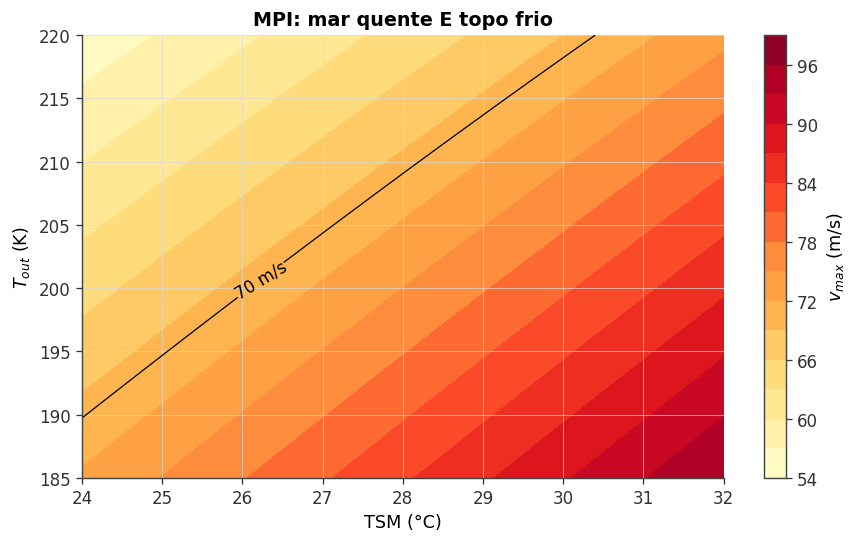

base (27 °C, 200 K): 72.3 m/s
+1 K de TSM: 75.0 m/s (+2.7) | -5 K no topo: 75.1 m/s (+2.7)
=> ~1 K de mar vale ~5 K de topo: Clausius-Clapeyron da TSM domina.


In [5]:
Ck_Cd, Lv = 0.9, 2.5e6
def es_kPa(T_C):
    return 0.6113*np.exp(5423*(1/273.15 - 1/(T_C + 273.15)))

SST = np.linspace(24, 32, 80)
Tout = np.linspace(185, 220, 80)
S, TO = np.meshgrid(SST, Tout)
r_sat = 622*es_kPa(S)/(101.3 - es_kPa(S))
dk = 0.2*Lv*r_sat/1000
VM = np.sqrt(Ck_Cd*(S + 273.15 - TO)/TO*dk)

fig, ax = plt.subplots(figsize=(9, 5))
cf = ax.contourf(S, TO, VM, levels=15, cmap='YlOrRd')
cs = ax.contour(S, TO, VM, levels=[33, 50, 70], colors='k', linewidths=0.8)
ax.clabel(cs, fmt='%.0f m/s')
ax.set(xlabel='TSM (°C)', ylabel='$T_{out}$ (K)',
       title='MPI: mar quente E topo frio')
fig.colorbar(cf, label='$v_{max}$ (m/s)')
plt.show()
v0 = np.sqrt(Ck_Cd*(300.15 - 200)/200*0.2*Lv*(622*es_kPa(27)/(101.3 - es_kPa(27)))/1000)
v_sst = np.sqrt(Ck_Cd*(301.15 - 200)/200*0.2*Lv*(622*es_kPa(28)/(101.3 - es_kPa(28)))/1000)
v_out = np.sqrt(Ck_Cd*(300.15 - 195)/195*0.2*Lv*(622*es_kPa(27)/(101.3 - es_kPa(27)))/1000)
print(f'base (27 °C, 200 K): {v0:.1f} m/s')
print(f'+1 K de TSM: {v_sst:.1f} m/s (+{v_sst-v0:.1f}) | -5 K no topo: {v_out:.1f} m/s (+{v_out-v0:.1f})')
print('=> ~1 K de mar vale ~5 K de topo: Clausius-Clapeyron da TSM domina.')

## N2 — Ajustando Holland a um furacão dado

In [6]:
from scipy.optimize import minimize

f = np.abs(2*Omega*np.sin(np.deg2rad(-20)))
r = np.linspace(2e3, 500e3, 3000)
alvo_v, alvo_r = 60.0, 25e3

def perfil(params):
    Pc, Rw, B = params
    dP = 101300 - Pc
    P = Pc + dP*np.exp(-(Rw/r)**B)
    dPdr = np.gradient(P, r)
    v = np.sqrt(np.maximum(r/rho_ar*dPdr, 0) + (f*r/2)**2) - f*r/2
    return v

def custo(params):
    v = perfil(params)
    return (v.max() - alvo_v)**2/25 + ((r[np.argmax(v)] - alvo_r)/5e3)**2

res = minimize(custo, x0=[94000, 30e3, 1.6], method='Nelder-Mead')
Pc, Rw, B = res.x
v = perfil(res.x)
print(f'ajuste: Pc = {Pc/100:.0f} hPa, Rw = {Rw/1e3:.0f} km, B = {B:.2f}')
print(f'vento máx = {v.max():.1f} m/s em r = {r[np.argmax(v)]/1e3:.0f} km')
print(f'ΔP = {(101300-Pc)/100:.0f} hPa -> categoria 4 (58-70 m/s) na escala')
print('Saffir-Simpson; consistente com dP ~ 60-70 hPa dos CT4 reais.')

ajuste: Pc = 945 hPa, Rw = 25 km, B = 1.68
vento máx = 60.0 m/s em r = 25 km
ΔP = 68 hPa -> categoria 4 (58-70 m/s) na escala
Saffir-Simpson; consistente com dP ~ 60-70 hPa dos CT4 reais.


## N3 — +2 K: o furacão do futuro

In [7]:
from tcpyPI import pi as tc_pi

P_lev = np.array([1000, 950, 900, 850, 800, 750, 700, 650, 600, 550, 500,
                  450, 400, 350, 300, 250, 200, 150, 100, 70, 50], dtype=float)
T_lev = np.array([27, 24.5, 22, 19.5, 17, 14.4, 11.5, 8.2, 4.6, 0.6, -3.8,
                  -8.8, -14.6, -21.4, -29.6, -39.5, -51.5, -66, -78, -75, -65], dtype=float)
r_lev = np.array([18, 16, 14, 12.5, 11, 9.5, 8, 6.5, 5.2, 4.0, 3.0,
                  2.2, 1.5, 1.0, 0.6, 0.3, 0.15, 0.05, 0.01, 0.005, 0.002], dtype=float)

v0, p0, *_ = tc_pi(28.0, 1013.0, P_lev, T_lev, r_lev)
# clima +2K: mar e troposfera aquecem (estratosfera nao), umidade +7%/K (CC)
T_fut = T_lev + np.where(P_lev >= 150, 2.0, 0.0)
r_fut = r_lev*1.07**2
v2, p2, *_ = tc_pi(30.0, 1013.0, P_lev, T_fut, r_fut)
print(f'presente (TSM 28): v_max = {v0:.0f} m/s, P_min = {p0:.0f} hPa')
print(f'futuro +2 K:       v_max = {v2:.0f} m/s, P_min = {p2:.0f} hPa')
print(f'intensificação: {100*(v2/v0 - 1)/2:.1f} %/K')
print()
print('poucos %/K no teto — mas dano eolico ~ v³ e chuva ~ +7%/K: o prejuizo')
print('cresce muito mais rapido que o v_max (discussao completa no Cap. 21).')

presente (TSM 28): v_max = 64 m/s, P_min = 948 hPa
futuro +2 K:       v_max = 68 m/s, P_min = 927 hPa
intensificação: 3.4 %/K

poucos %/K no teto — mas dano eolico ~ v³ e chuva ~ +7%/K: o prejuizo
cresce muito mais rapido que o v_max (discussao completa no Cap. 21).


## N4 — Vulnerabilidade da plataforma

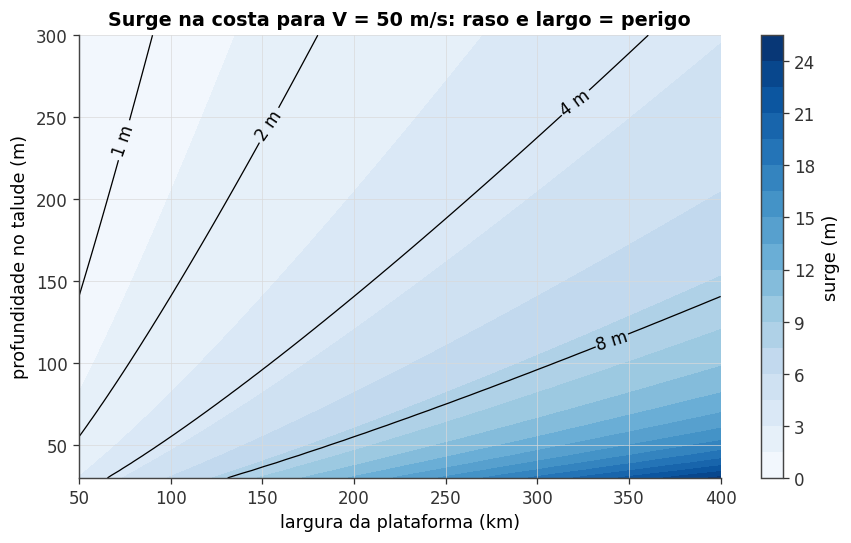

plataformas largas e rasas (tipo golfo do Mexico, Bangladesh) passam de 4 m;
no Brasil, o litoral sul/sudeste tem plataforma moderada — o risco maior
viria de ciclones extratropicais/subtropicais intensos (Catarina, 2004).


In [8]:
C_D, V = 2.5e-3, 50.0
tau = rho_ar*C_D*V**2

def surge_final(L_plat, h0, h_costa=3.0, n=3000):
    x = np.linspace(0, L_plat, n)
    h = h0 + (h_costa - h0)*x/L_plat
    return np.trapezoid(tau/(rho_agua*g*h), x)

Ls = np.linspace(50e3, 400e3, 60)
h0s = np.linspace(30, 300, 60)
LL, HH = np.meshgrid(Ls, h0s)
S = np.vectorize(surge_final)(LL, HH)

fig, ax = plt.subplots(figsize=(9, 5))
cf = ax.contourf(LL/1e3, HH, S, levels=15, cmap='Blues')
cs = ax.contour(LL/1e3, HH, S, levels=[1, 2, 4, 8], colors='k', linewidths=0.8)
ax.clabel(cs, fmt='%.0f m')
ax.set(xlabel='largura da plataforma (km)', ylabel='profundidade no talude (m)',
       title=f'Surge na costa para V = {V:.0f} m/s: raso e largo = perigo')
fig.colorbar(cf, label='surge (m)')
plt.show()
print('plataformas largas e rasas (tipo golfo do Mexico, Bangladesh) passam de 4 m;')
print('no Brasil, o litoral sul/sudeste tem plataforma moderada — o risco maior')
print('viria de ciclones extratropicais/subtropicais intensos (Catarina, 2004).')

---
*Material derivado de R. Stull, Practical Meteorology (CC BY-NC-SA 4.0); este notebook herda a mesma licença.*